<a href="https://colab.research.google.com/github/saltatt/Forecast-projects/blob/main/Cafe_profit_forecast.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ☕ Cafe Profit Forecast: will profit rise or fall by December?
Cafe kiosk inside a baby swimming studio (customers: parents and staff). Real data exists only for **August 2026**, so the model is simple and transparent:
**profit = sales × (1 − ingredient cost share) − fixed costs.**
Each section below shows one chart and how to read it. The seasonal numbers (marked ⚙️) are **assumptions** you can edit.

In [1]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
plt.rcParams.update({'figure.figsize':(11,4.2),'axes.grid':True,'grid.alpha':.3,'axes.spines.top':False,'axes.spines.right':False})
np.random.seed(1)

# August daily sales, KZT (day 1 = Sat 1 Aug 2026; unrecorded days omitted)
sales = {2:13000,3:6000,4:14000,5:9000,6:14500,7:14000,8:14000,9:6000,10:21000,11:6000,12:8100,
         13:17000,15:17000,16:16000,17:18000,18:8000,22:21000,23:23000,24:18000}
aug = pd.Series(sales); aug.index = pd.to_datetime('2026-08-' + aug.index.astype(str).str.zfill(2))
RENT, BARISTA, TARGET = 110_000, 65_000, 20_000
FIXED = RENT + BARISTA
avg = aug.mean()
print(f'{len(aug)} recorded days | average {avg:,.0f} KZT/day | days at/above {TARGET:,}: {(aug>=TARGET).sum()}')

19 recorded days | average 13,874 KZT/day | days at/above 20,000: 3


## 1. What August looked like
**How to read:** bars are daily sales; red line is the 20k target. The right chart shows which weekdays sell best.

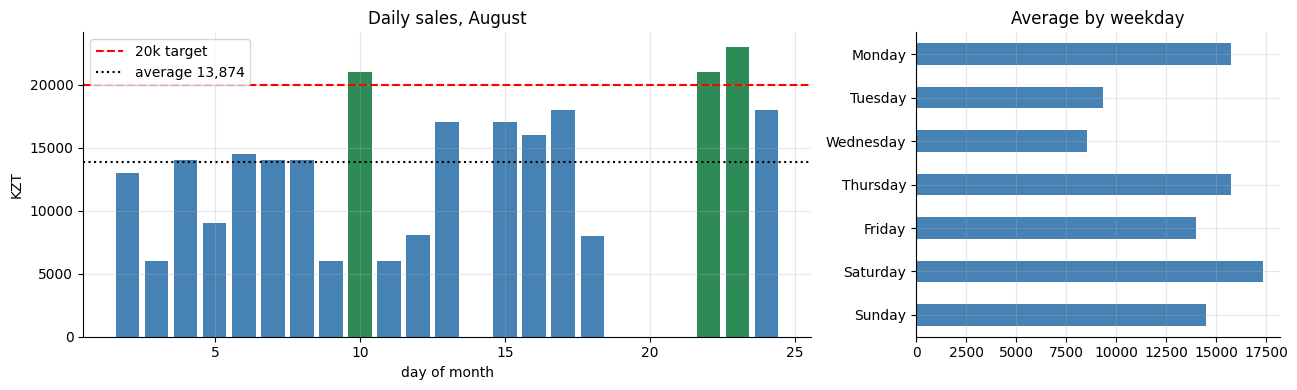

In [2]:
fig, ax = plt.subplots(1,2, figsize=(13,4), gridspec_kw={'width_ratios':[2,1]})
ax[0].bar(aug.index.day, aug.values, color=np.where(aug>=TARGET,'seagreen','steelblue'))
ax[0].axhline(TARGET, color='r', ls='--', label='20k target'); ax[0].axhline(avg, color='k', ls=':', label=f'average {avg:,.0f}')
ax[0].set(title='Daily sales, August', xlabel='day of month', ylabel='KZT'); ax[0].legend()
wd = aug.groupby(aug.index.day_name()).mean().reindex(['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']).dropna()
wd.plot.barh(ax=ax[1], color='steelblue', title='Average by weekday'); ax[1].invert_yaxis()
plt.tight_layout(); plt.show()

## 2. ⚙️ Assumptions: what people buy each month
Summer → cold drinks (iced coffee, lemonade, milkshakes, bottled drinks). Autumn/winter → hot drinks (coffee, karak chai, hot chocolate) and pastries. Kids' classes restart in September, so more parents wait on-site (`demand`).
- `demand` = sales level vs August · `days` = days in month · shares must sum to 100%
- `cost` = share of the price that goes to ingredients/wholesale goods: hot drinks are cheap to make (30%), resold cold drinks and bought pastries are not (55%).

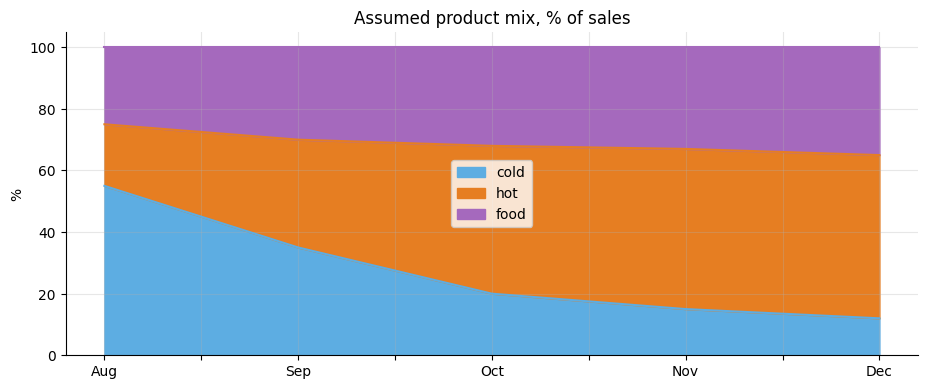

,demand,cogs
Aug,1.00,50.0
Sep,1.10,46.2
Oct,1.15,43.0
Nov,1.10,42.0
Dec,1.05,41.8


In [3]:
M = pd.DataFrame({'demand':[1.00,1.10,1.15,1.10,1.05], 'days':[31,30,31,30,31],
                  'cold':[.55,.35,.20,.15,.12], 'hot':[.20,.35,.48,.52,.53], 'food':[.25,.30,.32,.33,.35]},
                 index=['Aug','Sep','Oct','Nov','Dec'])
COST = {'cold':.55, 'hot':.30, 'food':.55}
M['cogs'] = sum(M[k]*v for k,v in COST.items())          # blended ingredient cost share
M.loc[:, ['cold','hot','food']].mul(100).plot.area(stacked=True, color=['#5dade2','#e67e22','#a569bd'], title='Assumed product mix, % of sales')
plt.ylabel('%'); plt.show()
M.assign(cogs=(M.cogs*100).round(1))[['demand','cogs']]

## 3. Forecast: profit by month
Each month: expected sales = August average × days × `demand`; profit = sales × (1 − cost share) − fixed costs (175k).
The band comes from 5,000 simulated months (random days sampled from August, `demand` uncertain ±12–16%). **Optimistic/pessimistic** = demand ×1.15 / ×0.85.

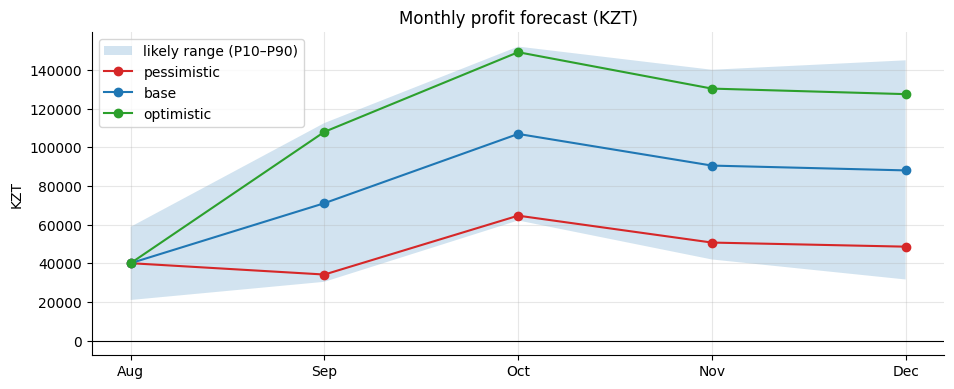

,pessimistic,base,optimistic
Aug,40042,40042,40042
Sep,34172,71084,107997
Oct,64632,106920,149208
Nov,50711,90542,130374
Dec,48593,88050,127508


In [4]:
def profit(m, k=1.0):  # expected profit for month m, demand scaled by k
    r = M.loc[m]; return avg*r.days*r.demand*k*(1-r.cogs) - FIXED
res = pd.DataFrame({s:[profit(m,k) for m in M.index] for s,k in {'pessimistic':.85,'base':1,'optimistic':1.15}.items()}, index=M.index)
res.loc['Aug'] = profit('Aug')                              # August is known, no scenarios
sd = dict(zip(M.index,[0,.12,.12,.14,.16]))
sim = {m: np.random.choice(aug.values,(5000,int(M.days[m]))).sum(axis=1)*np.random.normal(M.demand[m],sd[m]+1e-9,5000)*(1-M.cogs[m])-FIXED for m in M.index}
lo, hi = [pd.Series({m:np.percentile(sim[m],p) for m in M.index}) for p in (10,90)]

fig, ax = plt.subplots()
ax.fill_between(M.index, lo, hi, alpha=.2, label='likely range (P10–P90)')
for c,col in zip(res, ['tab:red','tab:blue','tab:green']): ax.plot(M.index, res[c], 'o-', color=col, label=c)
ax.axhline(0, color='k', lw=.8); ax.set(title='Monthly profit forecast (KZT)', ylabel='KZT'); ax.legend(); plt.show()
p_beat = {m:(sim[m] > res.loc['Aug','base']).mean() for m in M.index}
res.round(0).astype(int)

## 4. Why is it growing? (drivers, month by month)
Profit change vs August is split into three causes, so you can see **what mattered most and when**:
- 🟦 **Demand**: more customers/sales than August (school restart)
- 🟧 **Margin**: cheaper product mix (hot drinks replace resold cold drinks)
- ⬜ **Days**: 30 vs 31 days in the month

**How to read:** bars above zero push profit up, below zero push it down; the black dot is the total change.

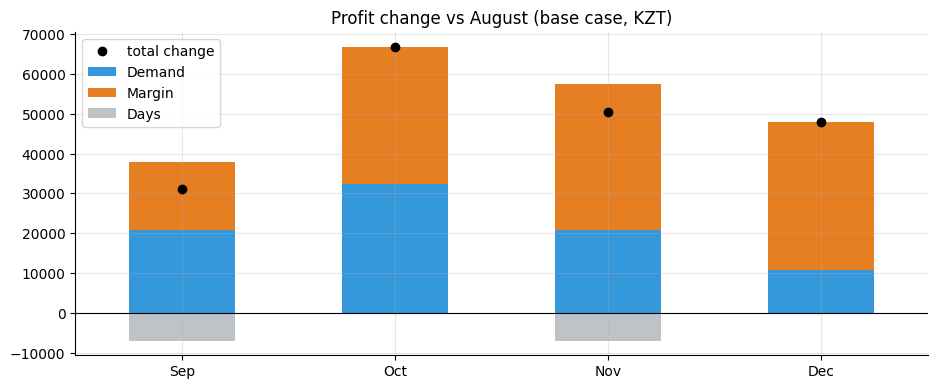

,Demand,Margin,Days,Total
Sep,20811,17169,-6937,31042
Oct,32256,34622,0,66878
Nov,20811,36627,-6937,50500
Dec,10752,37256,0,48008


In [5]:
a = M.loc['Aug']; base_p = profit('Aug')
D = pd.DataFrame({m:{'Demand':  avg*M.days[m]*(M.demand[m]-1)*(1-a.cogs),
                     'Margin':  avg*M.days[m]*M.demand[m]*(a.cogs-M.cogs[m]),
                     'Days':    avg*(M.days[m]-31)*(1-a.cogs)} for m in M.index[1:]}).T
D.plot.bar(stacked=True, color=['#3498db','#e67e22','#bdc3c7'], figsize=(11,4.2), rot=0)
plt.plot(range(4), D.sum(axis=1), 'ko', label='total change'); plt.axhline(0,color='k',lw=.8)
plt.title('Profit change vs August (base case, KZT)'); plt.legend(); plt.show()
D.round(0).astype(int).assign(Total=D.sum(axis=1).round(0).astype(int))

## 5. What matters most? (sensitivity for December)
Each bar shows how much **December profit** moves if one input changes by a realistic amount. Long bar = big influence, so that is where to focus.
Demand ±10% · ingredient cost ±3 points · rent ±10% · barista pay ±10%.

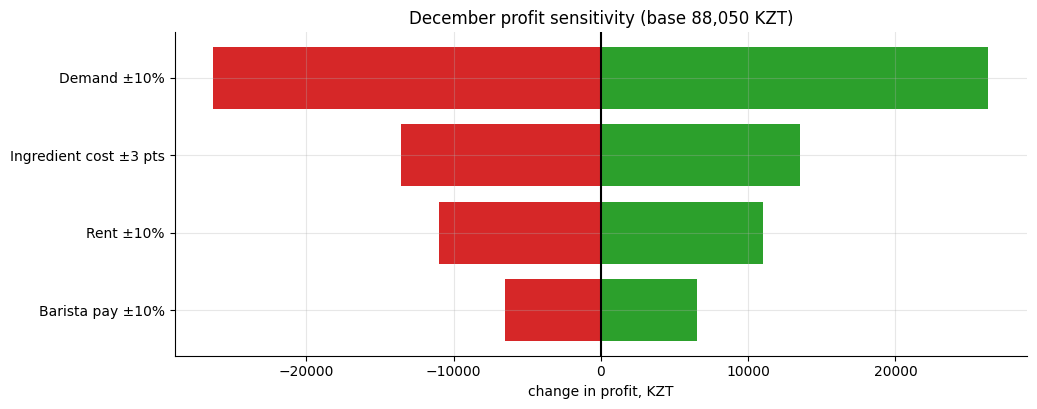

In [6]:
def dec(demand=1, cogs=0, rent=1, barista=1):
    r = M.loc['Dec']; return avg*r.days*r.demand*demand*(1-r.cogs-cogs) - RENT*rent - BARISTA*barista
b = dec()
T = pd.DataFrame({'Demand ±10%':(dec(demand=.9),dec(demand=1.1)), 'Ingredient cost ±3 pts':(dec(cogs=.03),dec(cogs=-.03)),
                  'Rent ±10%':(dec(rent=1.1),dec(rent=.9)), 'Barista pay ±10%':(dec(barista=1.1),dec(barista=.9))}, index=['worse','better']).T
T['w']=T.worse-b; T['g']=T.better-b; T = T.reindex((T.g-T.w).sort_values().index)
fig, ax = plt.subplots(); ax.barh(T.index, T.w, color='tab:red'); ax.barh(T.index, T.g, color='tab:green')
ax.axvline(0,color='k'); ax.set(title=f'December profit sensitivity (base {b:,.0f} KZT)', xlabel='change in profit, KZT'); plt.show()

## 5. What matters most? Sensitivity of December profit

### What this chart answers
The forecast rests on assumptions (how many customers come, what ingredients cost, what fixed costs are). Real life will differ a little. This chart shows **which input hurts or helps December profit the most if it turns out different from the assumption.**

### How to read it
- The center line is the **base forecast: 88,050 KZT** of profit in December.
- Each bar changes **one input at a time** and keeps everything else the same.
- 🟥 **Red (left)** is the bad direction: profit falls. 🟩 **Green (right)** is the good direction: profit rises.
- **The longer the bar, the more that input controls the result.**
- The inputs are changed by different amounts (10% for sales, rent and barista pay; 3 percentage points for ingredient cost). Read the bars as "how much a realistic surprise costs or earns", not as equal changes.

### Results

| Input | Change tested | Effect on December profit | What it means in practice |
|---|---|---|---|
| **Sales (demand)** | ±10% | about **±26,000 KZT** | 10% fewer customers or smaller checks leaves about 62k; 10% more gives about 114k |
| **Ingredient cost** | ±3 points | about **±13,500 KZT** | If ingredients take 45% of a sale instead of 42%, profit drops by about 13.5k |
| **Rent** | ±10% | about **±11,000 KZT** | Matters only if the rent is renegotiated or raised |
| **Barista pay** | ±10% | about **±6,500 KZT** | The smallest effect of the four |

### Conclusions
1. **Sales are the main lever.** A 10% change in sales moves profit about twice as much as any other factor. Attracting more parents and staff (a visible menu, a loyalty offer, special hot drinks, a set for parents waiting during classes) is worth more than any cost cutting.
2. **Ingredient cost is the second lever.** Small savings on wholesale pastries and resold drinks, or a shift toward hot drinks (cheaper to make), add up quickly.
3. **Fixed costs are less important.** Rent and barista pay are stable. They only change the result if the contract changes.
4. **The forecast is fairly safe.** Even if sales fall 10%, profit stays around 62k KZT. If all four inputs go wrong at once, profit would still be roughly 30k KZT, above zero.

### Limits
- Each bar changes only one input. In reality, several can change together.
- The seasonal demand and cost shares are **assumptions**, not measured data. Check them against real receipts every month.
- Even in the best cases the cafe stays below the **20,000 KZT per day** target, so growing sales is the priority.

## 6. Answer

In [7]:
d_dec = res.loc['Dec','base'] - res.loc['Aug','base']
peak = res.base.idxmax(); big = D.loc['Dec'].abs().drop('Days').idxmax()
need = (FIXED/(1-M.cogs['Dec']))/31
print(f"August profit (est.):         {res.loc['Aug','base']:>9,.0f} KZT")
print(f"December profit (base case):  {res.loc['Dec','base']:>9,.0f} KZT  ({d_dec:+,.0f})  → profit {'RISES' if d_dec>0 else 'FALLS'}")
print(f"Chance December beats August: {p_beat['Dec']:.0%}   (pessimistic case: {res.loc['Dec','pessimistic']:,.0f} KZT)")
print(f"Best month: {peak}. Biggest growth driver in December: {big}.")
print(f"Break-even sales in Dec: {need:,.0f} KZT/day; August average was {avg:,.0f}; target is {TARGET:,}.")
print("→ The cafe covers its costs but stays below the 20k/day target unless sales grow ~40%+ above August.")

August profit (est.):            40,042 KZT
December profit (base case):     88,050 KZT  (+48,008)  → profit RISES
Chance December beats August: 86%   (pessimistic case: 48,593 KZT)
Best month: Oct. Biggest growth driver in December: Margin.
Break-even sales in Dec: 9,691 KZT/day; August average was 13,874; target is 20,000.
→ The cafe covers its costs but stays below the 20k/day target unless sales grow ~40%+ above August.
